In [2]:
import pandas as pd
df=pd.read_csv("Housing.csv")
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [19]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [20]:
df.shape

(545, 13)

In [7]:
df.shape
df_no_null=df.dropna()

In [9]:
df_no_null.shape
df_clean = df_no_null.copy()

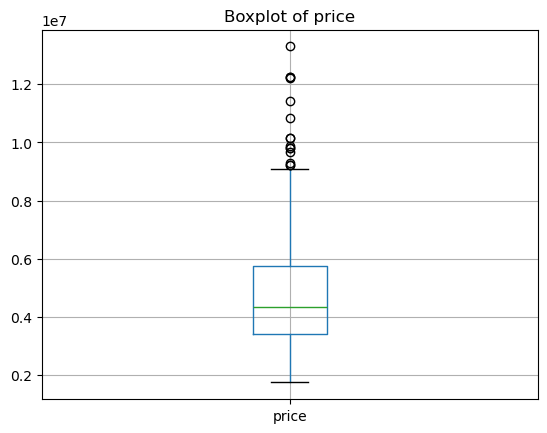

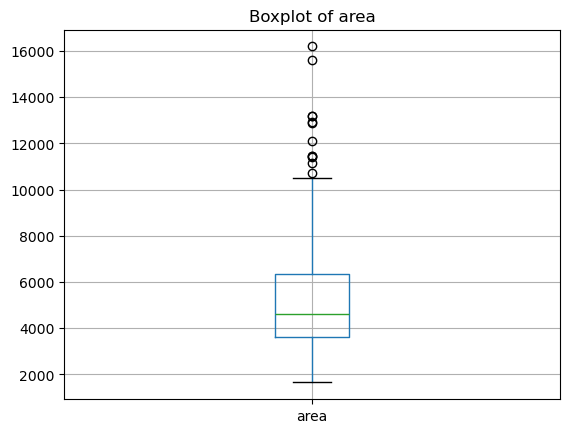

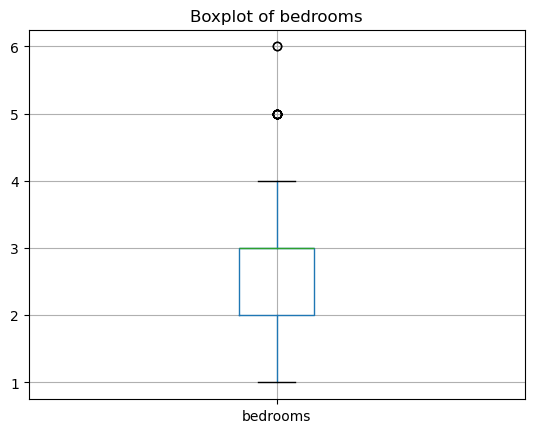

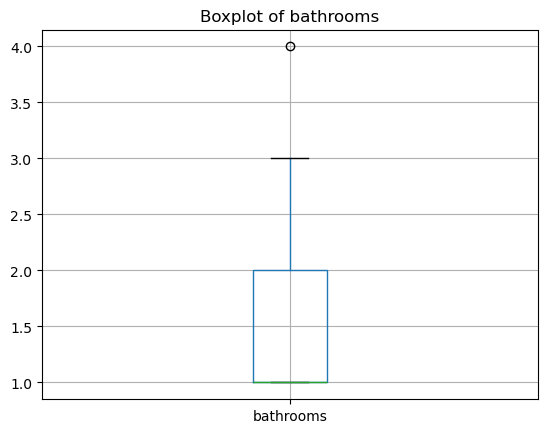

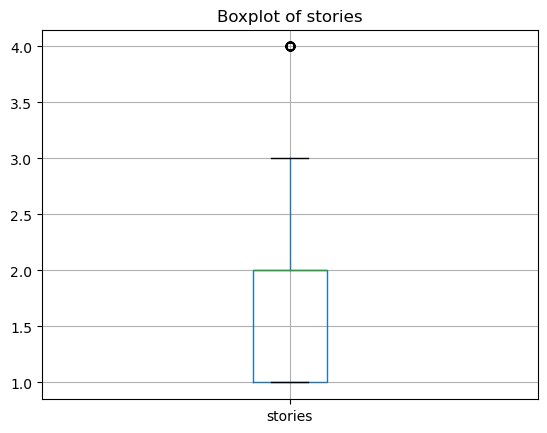

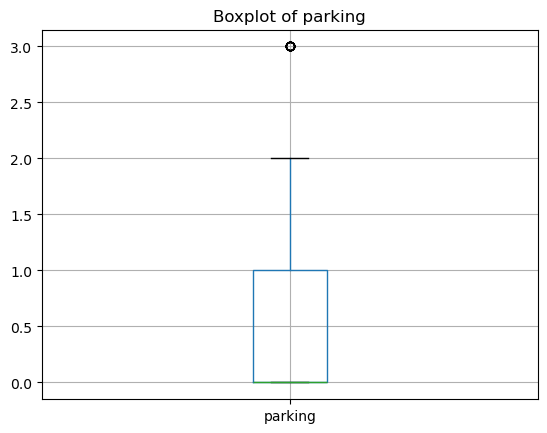

In [14]:
num_cols=df_clean.select_dtypes(include=["int64", "float64"]).columns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    df_no_null.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


In [15]:
outlier_count={}
for col in num_cols:
    q1=df_no_null[col].quantile(0.25)
    q3=df_no_null[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((df_clean[col]<lower) | (df_clean[col]>upper)).sum()
    outlier_count[col]=outliers

    df_clean=df_clean[(df_clean[col]>=lower) & df_clean[col]<=upper]

print("\nOutliers removed per column:")
for k, v in outlier_count.items():
    print(f"{k}: {v}")

print("\nFinal shape after removing outliers:", df_clean.shape)


Outliers removed per column:
price: 15
area: 12
bedrooms: 12
bathrooms: 1
stories: 41
parking: 12

Final shape after removing outliers: (545, 13)


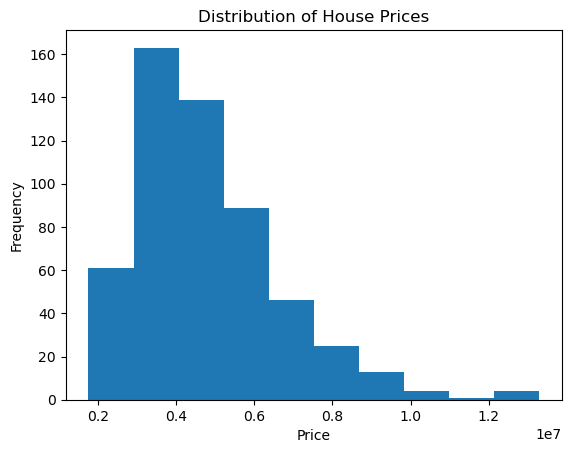

In [16]:
plt.figure()
plt.hist(df_clean["price"])
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


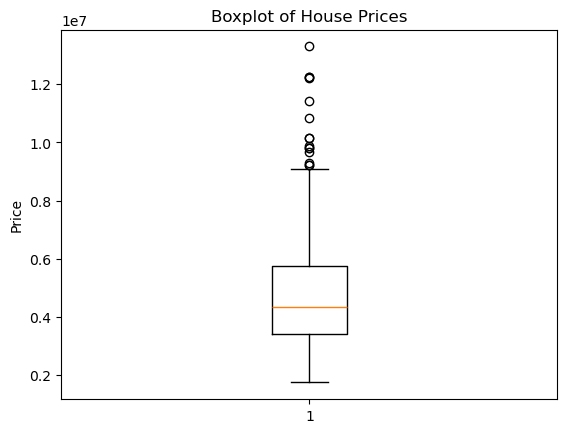

In [17]:
plt.figure()
plt.boxplot(df_clean["price"])
plt.title("Boxplot of House Prices")
plt.ylabel("Price")
plt.show()

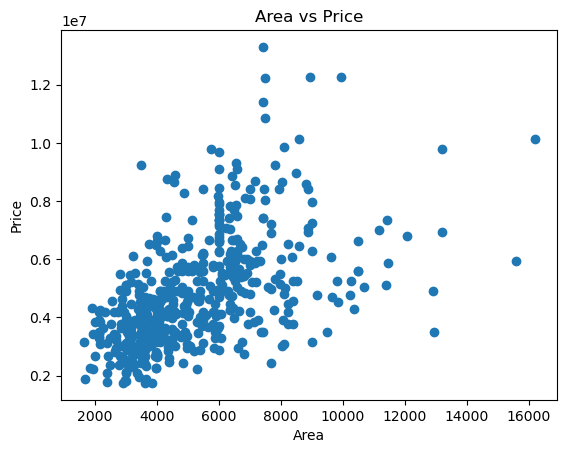

In [18]:
plt.figure()
plt.scatter(df_clean["area"], df_clean["price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()